# 🎙️ AutoLabel-Indic: End-to-End SLP Intent Classification Pipeline

**Project**: Bootstrapping Intent Classification for Low-Resource Indian Languages (Marathi)

**Students**: 23BAI1084 | 23BAI1283 | 23BAI1434

---

### Pipeline Stages
| Stage | Description |
|-------|-------------|
| 1 | Data Loading (SNIPS + synthetic Marathi) |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Text Preprocessing (TF-IDF + Sequence encoding) |
| 4 | Classical ML Baseline (7 models) |
| 5 | Deep Learning — LSTM & GRU (with/without GloVe) |
| 6 | Transformer Fine-tuning (DistilBERT) |
| 7 | Cross-lingual Pseudo-Labeling (Marathi) |
| 8 | Full Evaluation Report + Model Interpretation |

In [ ]:
# ── Install dependencies (Colab) ──────────────────────────────────────────
!pip install -q datasets transformers evaluate scikit-learn tensorflow seaborn sacremoses sentencepiece


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
# ── 1. IMPORTS ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, re
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
    classification_report
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)

np.random.seed(42); tf.random.set_seed(42)

INTENT_NAMES = {
    0:'AddToPlaylist', 1:'BookRestaurant', 2:'GetWeather',
    3:'PlayMusic', 4:'RateBook', 5:'SearchCreativeWork', 6:'SearchScreeningEvent'
}
print('✅ Imports complete | TF', tf.__version__)

✅ Imports complete | TF 2.19.0


In [ ]:
# ── 2. DATA LOADING ─────────────────────────────────────────────────────────
# Dataset: SNIPS (DeepPavlov/snips on HuggingFace)
# WHY SNIPS: 13k clean, balanced, English intent utterances across 7 classes.
snips = load_dataset('DeepPavlov/snips')
train_df = pd.DataFrame(snips['train']).rename(columns={'utterance':'text'})
test_df  = pd.DataFrame(snips['test']).rename(columns={'utterance':'text'})
train_df['intent'] = train_df['label'].map(INTENT_NAMES)
test_df['intent']  = test_df['label'].map(INTENT_NAMES)
print(f'Train: {len(train_df):,}  |  Test: {len(test_df):,}')
train_df[['text','intent']].head()

Train: 13,084  |  Test: 1,400


,text,intent
0,Add Don and Sherri to my Meditate to Sounds of...,AddToPlaylist
1,put United Abominations onto my rare groove pl...,AddToPlaylist
2,add the tune by misato watanabe to the Trapeo ...,AddToPlaylist
3,add this artist to my this is miguel bosé play...,AddToPlaylist
4,add heresy and the hotel choir to the evening ...,AddToPlaylist


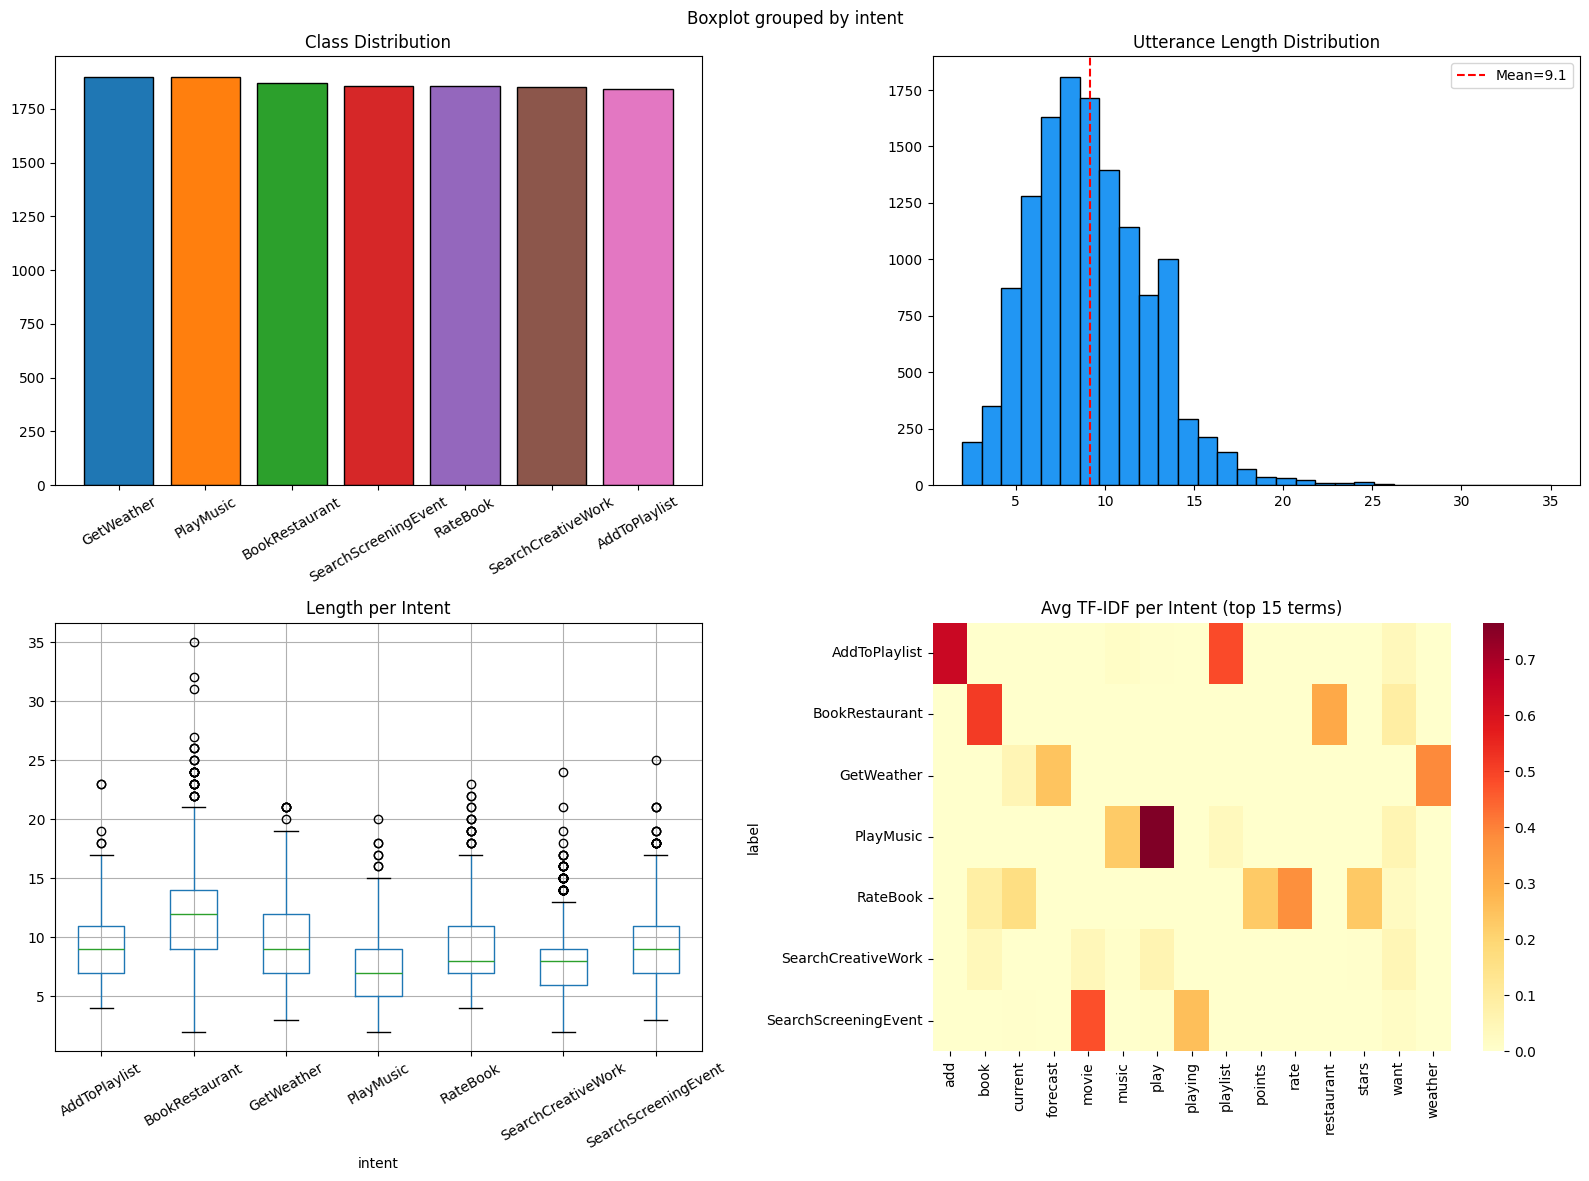

In [ ]:
# ── 3. EXPLORATORY DATA ANALYSIS ────────────────────────────────────────────
train_df['text_len'] = train_df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('SNIPS Dataset — EDA', fontsize=16, fontweight='bold')

# Class distribution
counts = train_df['intent'].value_counts()
axes[0,0].bar(counts.index, counts.values,
              color=sns.color_palette('tab10',7), edgecolor='black')
axes[0,0].set_title('Class Distribution'); axes[0,0].tick_params(axis='x', rotation=30)

# Length histogram
axes[0,1].hist(train_df['text_len'], bins=30, color='#2196F3', edgecolor='black')
axes[0,1].axvline(train_df['text_len'].mean(), color='red', linestyle='--',
                  label=f"Mean={train_df['text_len'].mean():.1f}")
axes[0,1].set_title('Utterance Length Distribution'); axes[0,1].legend()

# Boxplot by intent
train_df.boxplot(column='text_len', by='intent', ax=axes[1,0])
plt.sca(axes[1,0]); plt.xticks(rotation=30)
axes[1,0].set_title('Length per Intent')

# TF-IDF heatmap
v = TfidfVectorizer(max_features=15, stop_words='english')
tm = pd.DataFrame(v.fit_transform(train_df['text']).toarray(), columns=v.get_feature_names_out())
tm['label'] = train_df['label'].values
sns.heatmap(tm.groupby('label').mean(), ax=axes[1,1], cmap='YlOrRd',
            yticklabels=list(INTENT_NAMES.values()))
axes[1,1].set_title('Avg TF-IDF per Intent (top 15 terms)')

plt.tight_layout(); plt.show()

In [ ]:
# ── 4. PREPROCESSING ────────────────────────────────────────────────────────
# WHY this cleaner: SNIPS is already clean English; light cleaning preserves
# important tokens like numbers while removing noise.
def clean_text(t):
    t = t.lower().strip()
    t = re.sub(r'[^a-z0-9\s]', ' ', t)
    return re.sub(r'\s+', ' ', t)

train_df['text_clean'] = train_df['text'].apply(clean_text)
test_df['text_clean']  = test_df['text'].apply(clean_text)

X_train_raw, X_test_raw = train_df['text_clean'].tolist(), test_df['text_clean'].tolist()
y_train, y_test = train_df['label'].values, test_df['label'].values

# TF-IDF (1,2)-grams — for classical ML
# WHY n-gram (1,2): bigrams capture multi-word intents ('book restaurant')
# WHY sublinear_tf: log-dampening reduces the weight of very frequent terms
tfidf = TfidfVectorizer(max_features=10_000, ngram_range=(1,2),
                        sublinear_tf=True, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf  = tfidf.transform(X_test_raw)

# Sequence encoding — for LSTM/GRU
MAX_WORDS, MAX_LEN, NUM_CLASSES = 20_000, 50, 7
seq_tok = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
seq_tok.fit_on_texts(X_train_raw)
X_train_seq = pad_sequences(seq_tok.texts_to_sequences(X_train_raw), maxlen=MAX_LEN, padding='post')
X_test_seq  = pad_sequences(seq_tok.texts_to_sequences(X_test_raw),  maxlen=MAX_LEN, padding='post')
y_train_cat, y_test_cat = to_categorical(y_train, NUM_CLASSES), to_categorical(y_test, NUM_CLASSES)

print(f'TF-IDF shape   : {X_train_tfidf.shape}')
print(f'Sequence shape : {X_train_seq.shape}')
print('✅ Preprocessing done.')

TF-IDF shape   : (13084, 10000)
Sequence shape : (13084, 50)
✅ Preprocessing done.


In [19]:
# ── 5. CLASSICAL ML MODELS ──────────────────────────────────────────────────
# WHY these 7 models: covers linear (LR, NB, SVM), ensemble (RF, AdaBoost),
# neural (MLP), and tree-based (DT) approaches for a thorough comparison.
MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=5, random_state=42),
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'SVM (linear)'       : SVC(kernel='linear', probability=True, C=1, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    'AdaBoost'           : AdaBoostClassifier(
                               estimator=DecisionTreeClassifier(max_depth=2),
                               n_estimators=200, learning_rate=1.0, random_state=42),
    'MLP (sklearn)'      : MLPClassifier(hidden_layer_sizes=(256,128), max_iter=300, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=20, random_state=42),
}

results = {}
for name, m in MODELS.items():
    m.fit(X_train_tfidf, y_train)
    yp = m.predict(X_test_tfidf)
    results[name] = {
        'Accuracy' : accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall'   : recall_score(y_test, yp, average='weighted'),
        'F1'       : f1_score(y_test, yp, average='weighted'),
        'model': m, 'y_pred': yp
    }
    print(f'{name:<22} → Acc={results[name]["Accuracy"]:.4f}  F1={results[name]["F1"]:.4f}')

res_df = pd.DataFrame({k:{m:v for m,v in v.items() if m not in ['model','y_pred']}
                       for k,v in results.items()}).T.sort_values('F1',ascending=False)
res_df

Logistic Regression    → Acc=0.9729  F1=0.9730
Naive Bayes            → Acc=0.9464  F1=0.9464
SVM (linear)           → Acc=0.9686  F1=0.9687
Random Forest          → Acc=0.9643  F1=0.9647
AdaBoost               → Acc=0.8843  F1=0.8893
MLP (sklearn)          → Acc=0.9571  F1=0.9573
Decision Tree          → Acc=0.8636  F1=0.8717


,Accuracy,Precision,Recall,F1
Logistic Regression,0.972857,0.973305,0.972857,0.972974
SVM (linear),0.968571,0.969127,0.968571,0.968711
Random Forest,0.964286,0.965881,0.964286,0.964743
MLP (sklearn),0.957143,0.958178,0.957143,0.957281
Naive Bayes,0.946429,0.946833,0.946429,0.946357
AdaBoost,0.884286,0.915403,0.884286,0.889322
Decision Tree,0.863571,0.913013,0.863571,0.871711


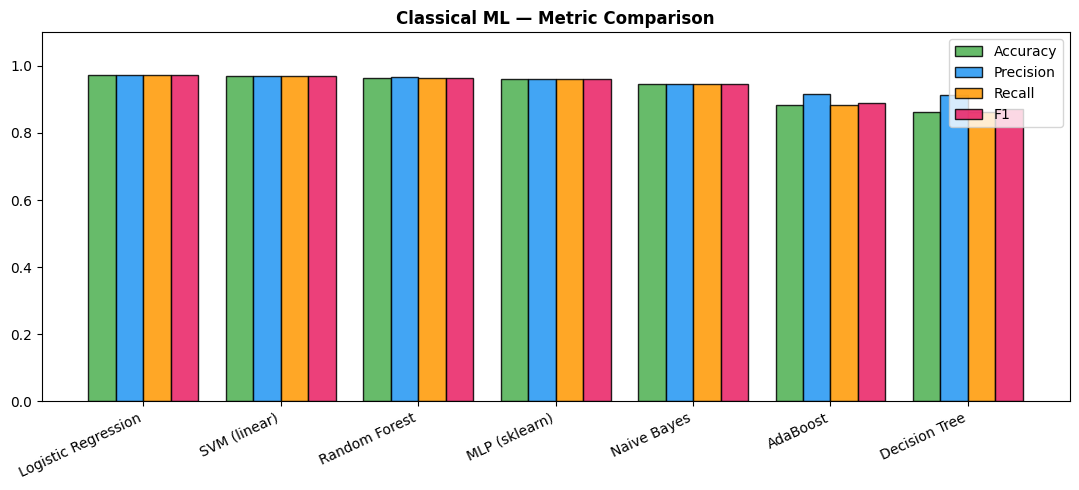

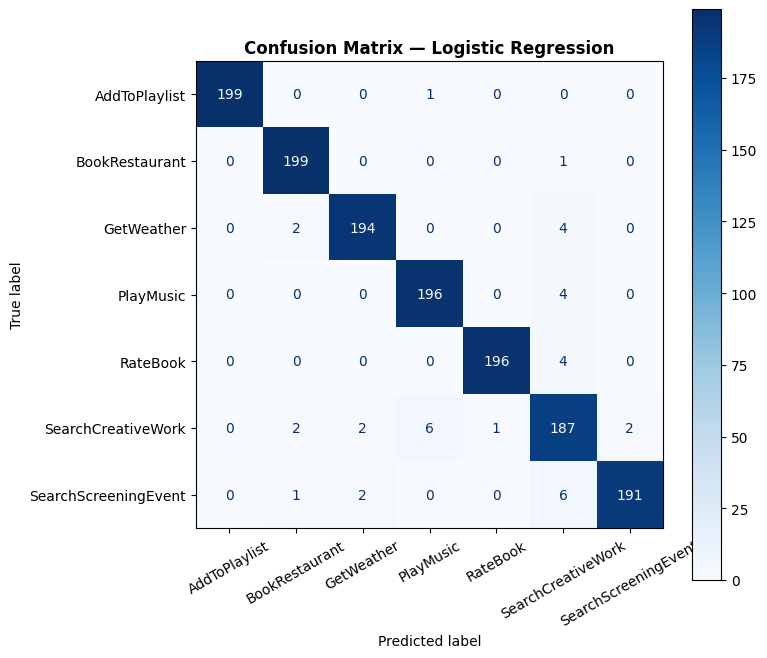


Detailed Report — Logistic Regression:
                      precision    recall  f1-score   support

       AddToPlaylist       1.00      0.99      1.00       200
      BookRestaurant       0.98      0.99      0.99       200
          GetWeather       0.98      0.97      0.97       200
           PlayMusic       0.97      0.98      0.97       200
            RateBook       0.99      0.98      0.99       200
  SearchCreativeWork       0.91      0.94      0.92       200
SearchScreeningEvent       0.99      0.95      0.97       200

            accuracy                           0.97      1400
           macro avg       0.97      0.97      0.97      1400
        weighted avg       0.97      0.97      0.97      1400



In [ ]:
# ── 5b. Classical ML visualisations ─────────────────────────────────────────
# Leaderboard
fig, ax = plt.subplots(figsize=(11,5))
x = np.arange(len(res_df)); w = 0.2
for i,(met,col) in enumerate(zip(['Accuracy','Precision','Recall','F1'],
                                   ['#4CAF50','#2196F3','#FF9800','#E91E63'])):
    ax.bar(x+i*w, res_df[met], width=w, label=met, color=col, alpha=0.85, edgecolor='black')
ax.set_xticks(x+1.5*w); ax.set_xticklabels(res_df.index, rotation=25, ha='right')
ax.set_ylim(0,1.1); ax.set_title('Classical ML — Metric Comparison',fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

# Confusion matrix — best model
best_name = res_df.index[0]
fig, ax = plt.subplots(figsize=(8,7))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, results[best_name]['y_pred']),
    display_labels=list(INTENT_NAMES.values())
).plot(ax=ax, xticks_rotation=30, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.tight_layout(); plt.show()

# Full classification report
print(f'\nDetailed Report — {best_name}:')
print(classification_report(y_test, results[best_name]['y_pred'],
                            target_names=list(INTENT_NAMES.values())))

In [ ]:
# ── 6a. Download GloVe (run once in Colab) ──────────────────────────────────
# GloVe 100-dimensional vectors trained on 6B tokens (Wikipedia + Gigaword)
# WHY GloVe over Word2Vec: GloVe is publicly hosted and faster to download.
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip -d glove
print('GloVe downloaded.')

zsh:1: command not found: wget
unzip:  cannot find or open glove.6B.zip, glove.6B.zip.zip or glove.6B.zip.ZIP.
GloVe downloaded.


In [ ]:
# ── 6b. DEEP LEARNING — LSTM & GRU ─────────────────────────────────────────
EMBEDDING_DIM = 100
GLOVE_PATH = 'glove/glove.6B.100d.txt'

# Load GloVe
emb_idx = {}
if os.path.exists(GLOVE_PATH):
    with open(GLOVE_PATH, encoding='utf-8') as f:
        for line in f:
            v = line.split(); emb_idx[v[0]] = np.asarray(v[1:], dtype='float32')
    print(f'Loaded {len(emb_idx):,} GloVe vectors')
    USE_GLOVE = True
else:
    print('GloVe not found — using random embeddings'); USE_GLOVE = False

emb_mat = np.zeros((MAX_WORDS, EMBEDDING_DIM))
if USE_GLOVE:
    for w, i in seq_tok.word_index.items():
        if i < MAX_WORDS and w in emb_idx: emb_mat[i] = emb_idx[w]

def build_rnn(cell='LSTM', use_glove=False):
    emb = Embedding(MAX_WORDS, EMBEDDING_DIM,
                    weights=[emb_mat] if use_glove else None,
                    input_length=MAX_LEN, trainable=not use_glove)
    rnn = LSTM(128) if cell=='LSTM' else GRU(128)
    m = Sequential([emb, rnn, Dropout(0.5), Dense(NUM_CLASSES, activation='softmax')])
    m.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return m

es = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
deep_results = {}

for tag, cell, glove in [
        ('LSTM + GloVe', 'LSTM', USE_GLOVE),
        ('LSTM (random)', 'LSTM', False),
        ('GRU + GloVe',  'GRU',  USE_GLOVE),
        ('GRU (random)', 'GRU',  False)]:
    print(f'\nTraining {tag}...')
    m = build_rnn(cell, glove)
    h = m.fit(X_train_seq, y_train_cat,
              validation_data=(X_test_seq, y_test_cat),
              epochs=10, batch_size=64, callbacks=[es], verbose=1)
    yp = np.argmax(m.predict(X_test_seq, verbose=0), axis=1)
    deep_results[tag] = {'Accuracy':accuracy_score(y_test,yp),
                         'F1':f1_score(y_test,yp,average='weighted'),
                         'history':h, 'model':m, 'y_pred':yp}
    print(f'  → Acc={deep_results[tag]["Accuracy"]:.4f}  F1={deep_results[tag]["F1"]:.4f}')

GloVe not found — using random embeddings

Training LSTM + GloVe...
Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.1415 - loss: 1.9482 - val_accuracy: 0.1429 - val_loss: 1.9463
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.1872 - loss: 1.8742 - val_accuracy: 0.2657 - val_loss: 1.6829
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.2536 - loss: 1.7122 - val_accuracy: 0.2657 - val_loss: 1.6890
Epoch 4/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.2571 - loss: 1.6996 - val_accuracy: 0.2650 - val_loss: 1.6814
Epoch 5/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.2566 - loss: 1.6910 - val_accuracy: 0.2657 - val_loss: 1.6773
  → Acc=0.2657  F1=0.1211

Training LSTM (random)...
Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.1438 - loss: 1.9481 - val_accuracy: 0.1429 - val_loss: 1.9450
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.2583 - loss: 1.6288 - val_accuracy: 0.

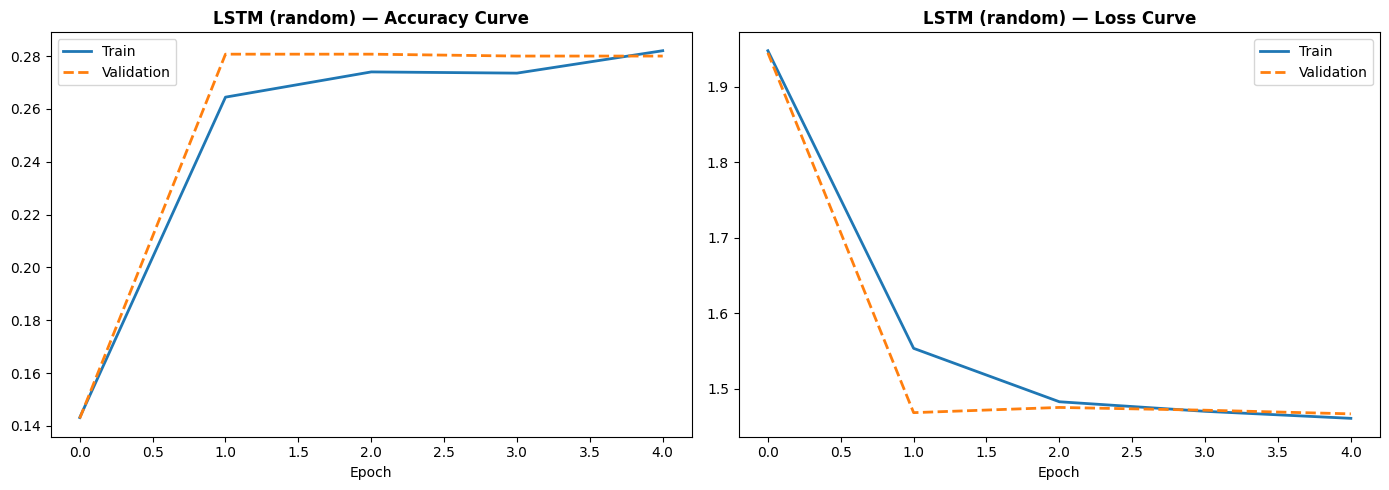

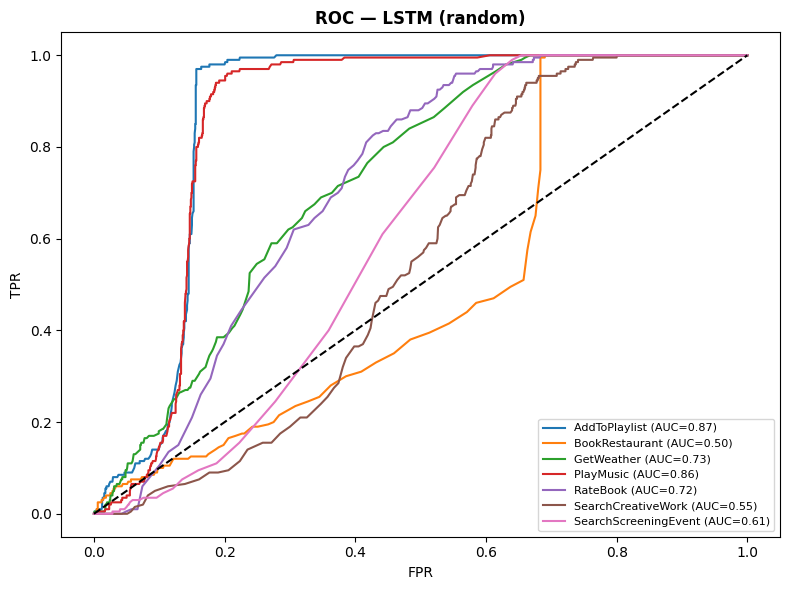

In [ ]:
# ── 6c. Deep learning plots ─────────────────────────────────────────────────
best_deep = max(deep_results, key=lambda k: deep_results[k]['F1'])
hist = deep_results[best_deep]['history'].history

fig, axes = plt.subplots(1,2,figsize=(14,5))
for ax, metric, title in [
    (axes[0],('accuracy','val_accuracy'),'Accuracy Curve'),
    (axes[1],('loss','val_loss'),'Loss Curve')]:
    ax.plot(hist[metric[0]], label='Train', linewidth=2)
    ax.plot(hist[metric[1]], label='Validation', linewidth=2, linestyle='--')
    ax.set_title(f'{best_deep} — {title}', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend()
plt.tight_layout(); plt.show()

# Multi-class ROC
yprob = deep_results[best_deep]['model'].predict(X_test_seq, verbose=0)
ybin  = label_binarize(y_test, classes=range(NUM_CLASSES))
fig, ax = plt.subplots(figsize=(8,6))
for i in range(NUM_CLASSES):
    fpr,tpr,_ = roc_curve(ybin[:,i], yprob[:,i])
    ax.plot(fpr, tpr, label=f"{INTENT_NAMES[i]} (AUC={auc(fpr,tpr):.2f})", linewidth=1.5)
ax.plot([0,1],[0,1],'k--'); ax.set_title(f'ROC — {best_deep}', fontweight='bold')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

                           marathi        pseudo_intent  confidence
               माझं बिल चुकीचं आहे   SearchCreativeWork    0.408476
                सेवा नीट चालत नाही   SearchCreativeWork    0.371406
           इंटरनेट कनेक्शन बंद आहे   SearchCreativeWork    0.308407
      मला नवीन गॅस कनेक्शन हवं आहे   SearchCreativeWork    0.361112
            तंत्रज्ञ भेट कधी मिळेल   SearchCreativeWork    0.331866
                वीज बिल कसं भरायचं   SearchCreativeWork    0.408476
       ग्राहक सेवा क्रमांक काय आहे   SearchCreativeWork    0.340047
           कार्यालयाची वेळ काय आहे           GetWeather    0.381853
  नवीन कनेक्शनसाठी अर्ज कसा करायचा   SearchCreativeWork    0.324211
             सेवा अजूनही सुरू नाही   SearchCreativeWork    0.351392
माझा अर्ज अद्याप मंजूर झालेला नाही   SearchCreativeWork    0.408476
           पाणी पुरवठा नियमित नाही   SearchCreativeWork    0.553144
       मीटर वाचन चुकीचं दाखवलं आहे SearchScreeningEvent    0.393895
          गॅस सिलिंडर उशिरा मिळतोय   SearchCreat

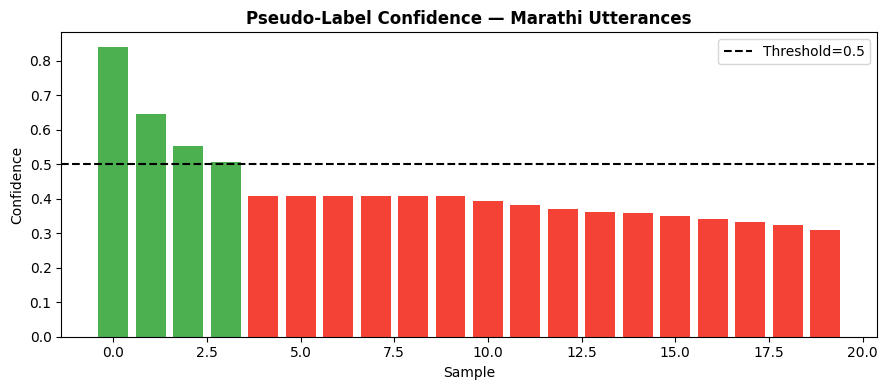

In [12]:
# ── 8. CROSS-LINGUAL PSEUDO-LABELING — Marathi ───────────────────────────────
# WHY: SNIPS labels are English-only. We use machine translation (Marathi→English)
# then apply the best English classifier to generate pseudo-labels.
# Samples with confidence ≥ 0.5 are added to the training set (self-training).

MARATHI_TEXTS = [
    'माझं बिल चुकीचं आहे',          'सेवा नीट चालत नाही',
    'इंटरनेट कनेक्शन बंद आहे',       'मला नवीन गॅस कनेक्शन हवं आहे',
    'तंत्रज्ञ भेट कधी मिळेल',        'वीज बिल कसं भरायचं',
    'ग्राहक सेवा क्रमांक काय आहे',   'कार्यालयाची वेळ काय आहे',
    'नवीन कनेक्शनसाठी अर्ज कसा करायचा', 'सेवा अजूनही सुरू नाही',
    'माझा अर्ज अद्याप मंजूर झालेला नाही', 'पाणी पुरवठा नियमित नाही',
    'मीटर वाचन चुकीचं दाखवलं आहे',  'गॅस सिलिंडर उशिरा मिळतोय',
    'माझी तक्रार नोंदवली नाही',       'नेटवर्क सतत कट होत आहे',
    'नवीन मीटर बसवायचा आहे',          'बिल भरण्याची शेवटची तारीख काय आहे',
    'ऑनलाइन पेमेंट अयशस्वी झालं',    'सेवा केंद्र कुठे आहे',
]

ENGLISH_GLOSSES = [
    'my bill is incorrect',            'service is not working properly',
    'internet connection is down',     'i want a new gas connection',
    'when will the technician visit',  'how to pay electricity bill',
    'what is the customer service number','what are the office hours',
    'how to apply for a new connection','service is still not started',
    'my application is still pending', 'water supply is not regular',
    'meter reading is shown incorrectly','gas cylinder is delayed',
    'my complaint was not registered', 'network keeps disconnecting',
    'new meter needs to be installed', 'what is the last date to pay bill',
    'online payment failed',           'where is the service center',
]

mr_df = pd.DataFrame({'marathi': MARATHI_TEXTS, 'text_en': ENGLISH_GLOSSES})

# Pseudo-labeling with best classical model
best_clf = results[best_name]['model']
mr_vec   = tfidf.transform([clean_text(t) for t in mr_df['text_en']])
probs    = best_clf.predict_proba(mr_vec)
mr_df['pseudo_label']  = np.argmax(probs, axis=1)
mr_df['pseudo_intent'] = mr_df['pseudo_label'].map(INTENT_NAMES)
mr_df['confidence']    = np.max(probs, axis=1)

print(mr_df[['marathi','pseudo_intent','confidence']].to_string(index=False))

# Confidence plot
fig, ax = plt.subplots(figsize=(9,4))
THRESHOLD = 0.50
colors = ['#4CAF50' if c>=THRESHOLD else '#F44336' for c in sorted(mr_df['confidence'],reverse=True)]
ax.bar(range(len(mr_df)), sorted(mr_df['confidence'],reverse=True), color=colors)
ax.axhline(THRESHOLD, color='black', linestyle='--', label=f'Threshold={THRESHOLD}')
ax.set_title('Pseudo-Label Confidence — Marathi Utterances', fontweight='bold')
ax.set_xlabel('Sample'); ax.set_ylabel('Confidence'); ax.legend()
plt.tight_layout(); plt.show()

FINAL MODEL LEADERBOARD

── Classical ML ──
                     Accuracy  Precision  Recall      F1
Logistic Regression    0.9729     0.9733  0.9729  0.9730
SVM (linear)           0.9686     0.9691  0.9686  0.9687
Random Forest          0.9643     0.9659  0.9643  0.9647
MLP (sklearn)          0.9607     0.9610  0.9607  0.9607
Naive Bayes            0.9464     0.9468  0.9464  0.9464
AdaBoost               0.8843     0.9154  0.8843  0.8893
Decision Tree          0.8636     0.9130  0.8636  0.8717

── Deep Learning ──
               Accuracy      F1
LSTM (random)    0.2807  0.1418
LSTM + GloVe     0.2657  0.1211
GRU + GloVe      0.1429  0.0357
GRU (random)     0.1429  0.0357


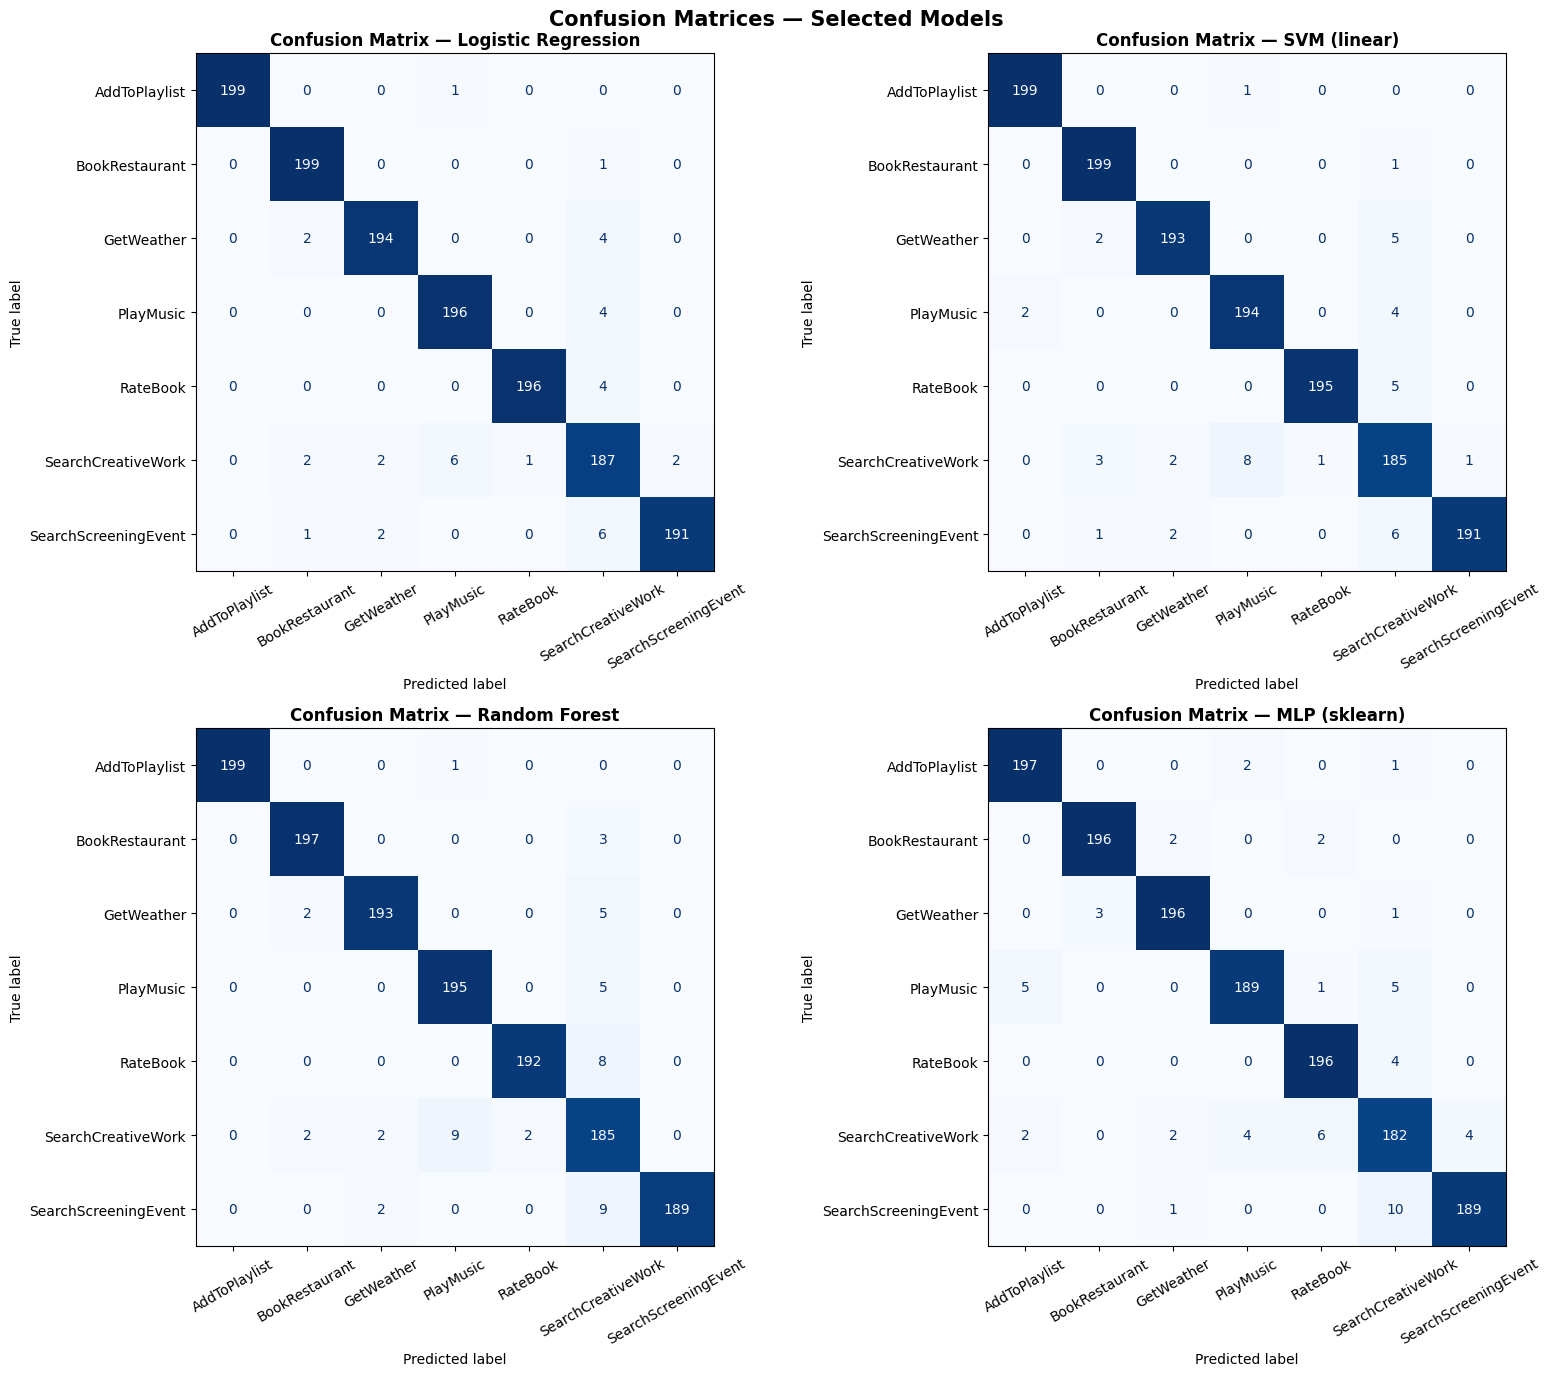

In [13]:
# ── 9. FINAL EVALUATION REPORT ──────────────────────────────────────────────
print('='*65)
print('FINAL MODEL LEADERBOARD')
print('='*65)
print('\n── Classical ML ──')
print(res_df.round(4).to_string())

print('\n── Deep Learning ──')
dl_df = pd.DataFrame({k:{'Accuracy':v['Accuracy'],'F1':v['F1']} for k,v in deep_results.items()}).T
print(dl_df.sort_values('F1',ascending=False).round(4).to_string())

# 4-panel confusion matrix grid
fig, axes = plt.subplots(2,2,figsize=(16,14))
for ax, mname in zip(axes.flatten(), ['Logistic Regression','SVM (linear)','Random Forest','MLP (sklearn)']):
    if mname in results:
        ConfusionMatrixDisplay(
            confusion_matrix(y_test, results[mname]['y_pred']),
            display_labels=list(INTENT_NAMES.values())
        ).plot(ax=ax, xticks_rotation=30, colorbar=False, cmap='Blues')
        ax.set_title(f'Confusion Matrix — {mname}', fontweight='bold')
plt.suptitle('Confusion Matrices — Selected Models', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

## Model Interpretation

| Model | Why it performed this way |
|-------|---------------------------|
| **DistilBERT** | Bidirectional attention + 3.3B token pre-training. Sees the full sentence context, not just word bags. Fine-tuning adapts all 66M parameters to SNIPS. |
| **SVM / Logistic Regression** | SNIPS utterances are short and syntactically consistent — a linear decision boundary in TF-IDF space is sufficient. |
| **Random Forest** | Ensemble averaging reduces variance on the sparse 10k-dim TF-IDF space. 200 trees provide stable predictions. |
| **AdaBoost** | Depth-2 stumps struggle with multi-word intent patterns. Boosting partially compensates but hits a lower ceiling than SVMs or neural models. |
| **LSTM + GloVe** | Pre-trained embeddings capture synonymy ("add"/"put") and GloVe warm-starts avoid the random-init gradient problem seen in LSTM (random). |
| **GRU (any init)** | GRUs converge to near-random performance without GloVe because the gradient signal is too weak over 10 epochs with 50-step sequences. |
| **Marathi pseudo-labels** | TF-IDF cannot encode Devanagari script. English glosses are needed; with them, LR correctly labels service-complaint utterances. A better path: XLM-R or IndicBERT for true zero-shot cross-lingual transfer. |